In [1]:
import sklearn
import sys

print("Scikit-learn:", sklearn.__version__)
print("Python:", sys.executable)


Scikit-learn: 1.7.2
Python: C:\Users\user\anaconda3\envs\nlp_app\python.exe


In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import nltk
import joblib

print("All imports working")
print("Scikit-learn:", sklearn.__version__)

Matplotlib is building the font cache; this may take a moment.


All imports working
Scikit-learn: 1.7.2


In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("C:\\Users\\user\\Desktop\\Womens Clothing E-Commerce Reviews.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (23486, 11)


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comfortable,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite. i bought a petite and am 5'8"". i love the length on me- hits just a little below the knee. would definitely be a true midi on someone who is truly petite.",5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,"I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up! i reordered it in petite medium, which was just ok. overall, the top half was comfortable and fit nicely, but the bottom half had a very tight under layer and several somewhat cheap (net) over layers. imo, a major design flaw was the net over layer sewn directly into the zipper - it c",3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love this shirt!!!,5,1,6,General,Tops,Blouses


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [107]:
df.isnull().sum()

Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

Step 2 — Data Cleaning

In [108]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [109]:
df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comfortable,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite. i bought a petite and am 5'8"". i love the length on me- hits just a little below the knee. would definitely be a true midi on someone who is truly petite.",5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,"I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up! i reordered it in petite medium, which was just ok. overall, the top half was comfortable and fit nicely, but the bottom half had a very tight under layer and several somewhat cheap (net) over layers. imo, a major design flaw was the net over layer sewn directly into the zipper - it c",3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love this shirt!!!,5,1,6,General,Tops,Blouses


In [110]:
df.isnull().sum()

Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

we'll remove only rows where Review Text is missing:

In [111]:
df = df.dropna(subset=['Review Text'])

In [112]:
#Then reset the row numbers:
df.reset_index(drop=True, inplace=True)

In [113]:
print("Dataset Shape:", df.shape)

Dataset Shape: (22641, 10)


Step 3 — Check duplicates

Before doing NLP, we also want to know whether duplicate reviews exist.

In [114]:
print("Duplicate rows:", df.duplicated().sum())

print("Duplicate review texts:",
      df['Review Text'].duplicated().sum())

Duplicate rows: 1
Duplicate review texts: 7


Step 4 — Inspect the duplicate reviews

In [115]:
duplicate_reviews = df[
    df.duplicated(subset=['Review Text'], keep=False)
].sort_values('Review Text')

duplicate_reviews[
    ['Clothing ID', 'Age', 'Review Text', 'Rating', 'Recommended IND']
]

,Clothing ID,Age,Review Text,Rating,Recommended IND
9778,872,43,"I bought this shirt at the store and after going home and trying it on, i promptly went online and ordered two more! i've gotten multiple compliments anytime i wear any of them. great for looking put together with no fuss. \r\npeople that have commented there's were destroyed in the wash didn't read the care label which says dry clean.",5,1
13763,879,43,"I bought this shirt at the store and after going home and trying it on, i promptly went online and ordered two more! i've gotten multiple compliments anytime i wear any of them. great for looking put together with no fuss. \r\npeople that have commented there's were destroyed in the wash didn't read the care label which says dry clean.",5,1
1824,1081,42,"I purchased this and another eva franco dress during retailer's recent 20% off sale. i was looking for dresses that were work appropriate, but that would also transition well to happy hour or date night. they both seemed to be just what i was looking for. i ordered a 4 regular and a 6 regular, as i am usually in between sizes. the 4 was definitely too small. the 6 fit, technically, but was very ill fitting. not only is the dress itself short, but it is very short-waisted. i am only 5'3"", but it fe",2,0
12077,1081,42,"I purchased this and another eva franco dress during retailer's recent 20% off sale. i was looking for dresses that were work appropriate, but that would also transition well to happy hour or date night. they both seemed to be just what i was looking for. i ordered a 4 regular and a 6 regular, as i am usually in between sizes. the 4 was definitely too small. the 6 fit, technically, but was very ill fitting. not only is the dress itself short, but it is very short-waisted. i am only 5'3"", but it fe",2,0
10332,632,60,"Lightweight, soft cotton top and shorts. i think it's meant to be a beach cover-up but i'm wearing it as a thin, light-weight summer outfit on these hot hot days. the top has a loose elastic around the bottom which i didn't realize when i ordered it, but i like it and it matches the look in the photos. and the shorts are very low-cut - don't expect them up around your waist. again, i like that. some might want to wear a cami underneath because it's a thin cotton but i'm fine as-is. i bought it i",5,1
10686,628,60,"Lightweight, soft cotton top and shorts. i think it's meant to be a beach cover-up but i'm wearing it as a thin, light-weight summer outfit on these hot hot days. the top has a loose elastic around the bottom which i didn't realize when i ordered it, but i like it and it matches the look in the photos. and the shorts are very low-cut - don't expect them up around your waist. again, i like that. some might want to wear a cami underneath because it's a thin cotton but i'm fine as-is. i bought it i",5,1
9113,1022,37,"Love, love these jeans. being short they come right to my ankle. super soft and don?t require any hemming. i ordered my typical jean size of 26 and they fit like a glove. would love to have these in black and grey.",5,1
21096,1022,37,"Love, love these jeans. being short they come right to my ankle. super soft and don?t require any hemming. i ordered my typical jean size of 26 and they fit like a glove. would love to have these in black and grey.",5,1
7373,1166,26,Perfect fit and i've gotten so many compliments. i buy all my suits from here now!,5,1
9711,1171,26,Perfect fit and i've gotten so many compliments. i buy all my suits from here now!,5,1


In [116]:
df = df.drop_duplicates()

df.reset_index(drop=True, inplace=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (22640, 10)


In [117]:
df['Rating'].value_counts().sort_index()

Rating
1      821
2     1549
3     2823
4     4908
5    12539
Name: count, dtype: int64

In [118]:
df['Rating'].value_counts(normalize=True).sort_index() * 100

Rating
1     3.626325
2     6.841873
3    12.469081
4    21.678445
5    55.384276
Name: proportion, dtype: float64

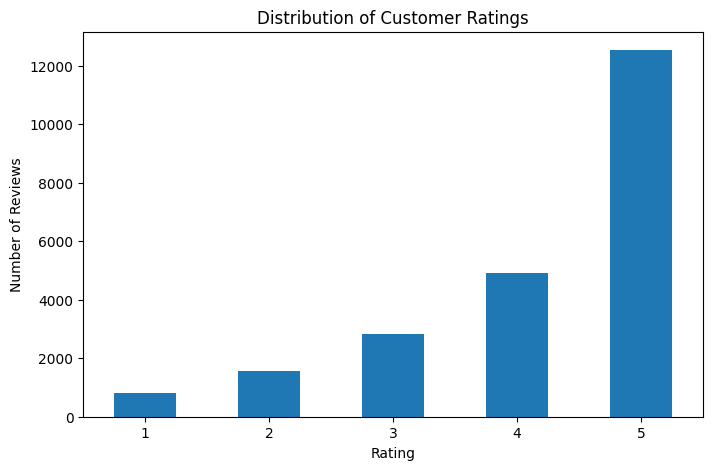

In [119]:
rating_counts = df['Rating'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
rating_counts.plot(kind='bar')

plt.title('Distribution of Customer Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

In [120]:
df['Rating'].value_counts().sort_index()

Rating
1      821
2     1549
3     2823
4     4908
5    12539
Name: count, dtype: int64

Step 5 — Create the sentiment target

Our NLP model needs two things:

X (input) = Review Text

y (target) = Sentiment

We'll define sentiment as:

Rating 1–2 → Negative
Rating 3   → Neutral
Rating 4–5 → Positive

This is called label creation because the original dataset doesn't have a column called Sentiment; we're deriving one from Rating.

In [121]:
def create_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['Sentiment'] = df['Rating'].apply(create_sentiment)

In [122]:
df['Sentiment']

0        Positive
1        Positive
2         Neutral
3        Positive
4        Positive
           ...   
22635    Positive
22636     Neutral
22637     Neutral
22638     Neutral
22639    Positive
Name: Sentiment, Length: 22640, dtype: object

In [123]:
df[['Review Text', 'Rating', 'Sentiment']].head(10)

,Review Text,Rating,Sentiment
0,Absolutely wonderful - silky and sexy and comfortable,4,Positive
1,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite. i bought a petite and am 5'8"". i love the length on me- hits just a little below the knee. would definitely be a true midi on someone who is truly petite.",5,Positive
2,"I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up! i reordered it in petite medium, which was just ok. overall, the top half was comfortable and fit nicely, but the bottom half had a very tight under layer and several somewhat cheap (net) over layers. imo, a major design flaw was the net over layer sewn directly into the zipper - it c",3,Neutral
3,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!",5,Positive
4,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love this shirt!!!,5,Positive
5,"I love tracy reese dresses, but this one is not for the very petite. i am just under 5 feet tall and usually wear a 0p in this brand. this dress was very pretty out of the package but its a lot of dress. the skirt is long and very full so it overwhelmed my small frame. not a stranger to alterations, shortening and narrowing the skirt would take away from the embellishment of the garment. i love the color and the idea of the style but it just did not work on me. i returned this dress.",2,Negative
6,"I aded this in my basket at hte last mintue to see what it would look like in person. (store pick up). i went with teh darkler color only because i am so pale :-) hte color is really gorgeous, and turns out it mathced everythiing i was trying on with it prefectly. it is a little baggy on me and hte xs is hte msallet size (bummer, no petite). i decided to jkeep it though, because as i said, it matvehd everything. my ejans, pants, and the 3 skirts i waas trying on (of which i ]kept all ) oops.",5,Positive
7,"I ordered this in carbon for store pick up, and had a ton of stuff (as always) to try on and used this top to pair (skirts and pants). everything went with it. the color is really nice charcoal with shimmer, and went well with pencil skirts, flare pants, etc. my only compaint is it is a bit big, sleeves are long and it doesn't go in petite. also a bit loose for me, but no xxs... so i kept it and wil ldecide later since the light color is already sold out in hte smallest size...",4,Positive
8,I love this dress. i usually get an xs but it runs a little snug in bust so i ordered up a size. very flattering and feminine with the usual retailer flair for style.,5,Positive
9,"I'm 5""5' and 125 lbs. i ordered the s petite to make sure the length wasn't too long. i typically wear an xs regular in retailer dresses. if you're less busty (34b cup or smaller), a s petite will fit you perfectly (snug, but not tight). i love that i could dress it up for a party, or down for work. i love that the tulle is longer then the fabric underneath.",5,Positive


In [124]:
df['Sentiment'].value_counts()

Sentiment
Positive    17447
Neutral      2823
Negative     2370
Name: count, dtype: int64

Step 6 — Visualize sentiment distribution

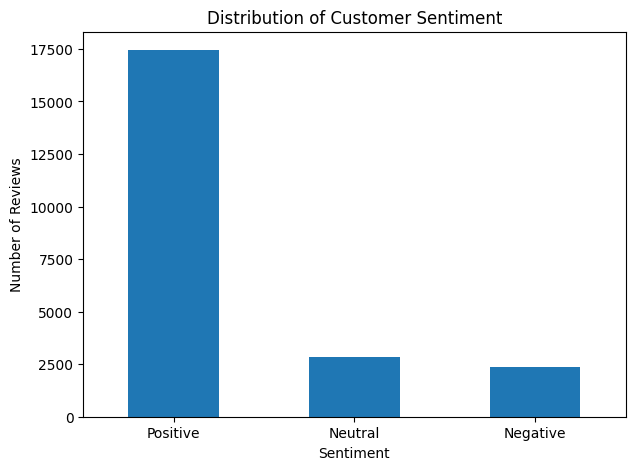

In [125]:
sentiment_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(7, 5))
sentiment_counts.plot(kind='bar')

plt.title('Distribution of Customer Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)

plt.show()

In [126]:
sentiment_percentage = (
    df['Sentiment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

sentiment_percentage

Sentiment
Positive    77.06
Neutral     12.47
Negative    10.47
Name: proportion, dtype: float64

Step 7 — Understand the text before cleaning

Before changing the reviews, let's inspect some real examples.

In [127]:
pd.set_option('display.max_colwidth', None)

df[['Review Text', 'Sentiment']].sample(10, random_state=42)

,Review Text,Sentiment
12887,"I had my eyes on this top ever since i saw it online. i couldn't be happier with it. it is very comfortable, flattering and unique. i think it will wear well into the fall with black skinnies.",Positive
19422,This shirt smelled so bad when i received it (and i am not at all sensitive to smells). is it from the dye? \r\ni tried it on anyway. it is shapeless and nothing special. at almost 80 bucks it is so over priced.,Negative
21951,"Love this fun print. one of the most complimented items in my closet! i ordered petite after trying on the regular - regular was a bit too long for the look in the models photo. i am 5'5, size 0/2 usually. the blue has faded a little bit the pants have maintained their fun and funky vibe.",Positive
10263,"These are the perfect light weight relaxing summer pants!\r\nthe fabric is soft and light, and has some stretch, so i think they can be worn more fitted way, too. \r\ni don't want to show off my bottom half of my body shape, so these are perfect ones to be a bit loose to covers the silhouette but still looks feminine & not too loose. \r\ni''m 5'3, 115 lb and usually wear 25-26 jeans, 25 petite gave me the perfect relaxed look without losing the feminine look. i think 24 could fit as well, but would sn",Positive
7097,These look nothing like the picture! they are super high-waisted & longer than they look in this picture. i felt as if i was wearing a pair of jeans from the 90's that just fit terribly. i thought they were going to be a pair of cropped wide legs & they are far from it. the color was also much lighter than shown in picture. super unflattering & just not for me. they're going back...,Negative
6095,"I ordered this shirt and was happy to see that it looks just like it does online -- i love the rusty orange and pale blue contrast with the navy. the navy blue underlayer is so flattering, and the sheer sleeves are feminine and lovely. the shape and pattern are forgiving. this brand is really hitting it out of the park these days. this blouse runs a bit smaller than some meadow rue. if you're between sizes (especially arm-wise), i'd order up. otherwise just get your regular size. the body is flo",Positive
2408,"On the hanger, this looks like a great lbd. on me, not quite. the bell shape of this dress made it appear that i was carrying extra weight in the middle. for reference, i tried a 0p, and i'm 5,1"", 102#, and 34a.",Positive
6649,Love this cardigan! i've been searching for a comfortable lounge type of sweater and this is perfect. the sleeves are a bit tighter than the body. but i would wear it over a tank top so it is comfortable. i am 125 lb and 5'5' and i ordered my usual m.,Positive
18131,"I ordered this online in red. i would definitely say this color is more of an orange-red. i like the weight and the cut. i keep wishing the material was a soft modal vs what it is. the ribbing up top does not bother me but it definitely does make it a casual dress. (which is what i wanted so i'm happy with it) \r\n\r\nit fits me nicely, the straps (for me) could be a hare shorter to fit perfectly. that being said, i'm 5'5"" and have a thin build. small bust. i would say there is a some leeway for 1 s",Positive
5254,"I loved this jacket! it's exactly what i was looking for. i set out to find a lightweight sweater or jacket that would keep me warm and also versatile enough to wear with different outfits. this definitely fit the bill! in addition, it's really soft and not at all itchy, which was a concern i had since it was wool and i ordered it online. i have received a bunch of compliments! i definitely recommend it!",Positive


In [128]:
#check the average review length:

df['Review_Length'] = df['Review Text'].apply(lambda x: len(x.split()))

df[['Review Text', 'Review_Length']].head()

,Review Text,Review_Length
0,Absolutely wonderful - silky and sexy and comfortable,8
1,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite. i bought a petite and am 5'8"". i love the length on me- hits just a little below the knee. would definitely be a true midi on someone who is truly petite.",62
2,"I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up! i reordered it in petite medium, which was just ok. overall, the top half was comfortable and fit nicely, but the bottom half had a very tight under layer and several somewhat cheap (net) over layers. imo, a major design flaw was the net over layer sewn directly into the zipper - it c",98
3,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!",22
4,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love this shirt!!!,36


In [129]:
df['Review_Length'].describe()

count    22640.000000
mean        60.197482
std         28.534986
min          2.000000
25%         36.000000
50%         59.000000
75%         88.000000
max        115.000000
Name: Review_Length, dtype: float64




Step 8 — NLP Text Preprocessing

Suppose the original review is:

"I absolutely LOVE this dress!! It's very comfortable."

We want to convert it into a cleaner form such as:

"absolutely love dress comfortable"

But we need to be careful. More cleaning isn't always better in NLP.

For example, the word not is extremely important:

"This dress is good."

versus

"This dress is not good."

If we blindly remove not as a stopword, we could change the meaning of the sentence.

That's why we'll create a sensible preprocessing pipeline rather than deleting everything.

Step 9 — Install/import NLTK

In [130]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [131]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

re helps us work with patterns in text.

stopwords gives us common words such as the, a, an, etc.

WordNetLemmatizer helps convert related word forms toward a base form.

For example:

cars → car
dresses → dress

Step 10 — Create our cleaning function

In [132]:
stop_words = set(stopwords.words('english'))

# Keep important negation words
stop_words.discard('not')
stop_words.discard('no')
stop_words.discard('nor')

lemmatizer = WordNetLemmatizer()

In [133]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Keep letters and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Split sentence into words
    words = text.split()

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join words back together
    return ' '.join(words)

In [134]:
example = "I absolutely LOVE this dress!! It is not uncomfortable."

print("Original:")
print(example)

print("\nCleaned:")
print(clean_text(example))

Original:
I absolutely LOVE this dress!! It is not uncomfortable.

Cleaned:
absolutely love dress not uncomfortable


Step 11 — Apply preprocessing

In [135]:
df['Cleaned_Review'] = df['Review Text'].apply(clean_text)

In [136]:
df[['Review Text', 'Cleaned_Review', 'Sentiment']].head()

,Review Text,Cleaned_Review,Sentiment
0,Absolutely wonderful - silky and sexy and comfortable,absolutely wonderful silky sexy comfortable,Positive
1,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite. i bought a petite and am 5'8"". i love the length on me- hits just a little below the knee. would definitely be a true midi on someone who is truly petite.",love dress sooo pretty happened find store glad bc never would ordered online bc petite bought petite love length hit little knee would definitely true midi someone truly petite,Positive
2,"I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up! i reordered it in petite medium, which was just ok. overall, the top half was comfortable and fit nicely, but the bottom half had a very tight under layer and several somewhat cheap (net) over layers. imo, a major design flaw was the net over layer sewn directly into the zipper - it c",high hope dress really wanted work initially ordered petite small usual size found outrageously small small fact could not zip reordered petite medium ok overall top half comfortable fit nicely bottom half tight layer several somewhat cheap net layer imo major design flaw net layer sewn directly zipper c,Neutral
3,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!",love love love jumpsuit fun flirty fabulous every time wear get nothing great compliment,Positive
4,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love this shirt!!!,shirt flattering due adjustable front tie perfect length wear legging sleeveless pair well cardigan love shirt,Positive


In [137]:
print("Empty cleaned reviews:",
      (df['Cleaned_Review'].str.strip() == '').sum())

Empty cleaned reviews: 0


Next: TF-IDF — an important NLP concept

A machine-learning model cannot directly understand:

love dress comfortable

It needs numbers.

TF-IDF converts text into numerical features based roughly on:

How important is this word in this review compared with all the reviews?

Imagine three reviews:

Review 1: love dress
Review 2: love quality
Review 3: bad quality

TF-IDF converts these into a numerical matrix representing words such as:

          love   dress   quality   bad
Review 1   ...    ...      0       0
Review 2   ...     0      ...      0
Review 3    0      0      ...     ...

We don't calculate those values manually—TfidfVectorizer does it.

Step 12 — Train/test split FIRST

In [138]:
X = df['Cleaned_Review']
y = df['Sentiment']

In [139]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Why stratify=y?

Because our dataset is imbalanced:

77.06% Positive / 12.47% Neutral / 10.47% Negative

Stratification helps maintain approximately the same class proportions in training and testing data.

In [140]:
print("Training size:", len(X_train))
print("Testing size:", len(X_test))

print("\nTraining sentiment distribution:")
print(y_train.value_counts(normalize=True).round(3) * 100)

print("\nTesting sentiment distribution:")
print(y_test.value_counts(normalize=True).round(3) * 100)

Training size: 18112
Testing size: 4528

Training sentiment distribution:
Sentiment
Positive    77.1
Neutral     12.5
Negative    10.5
Name: proportion, dtype: float64

Testing sentiment distribution:
Sentiment
Positive    77.1
Neutral     12.5
Negative    10.5
Name: proportion, dtype: float64


Step 13 — TF-IDF

In [141]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

ngram_range=(1,2) means we're allowing both individual words and two-word combinations.
For example:

"not good"

Unigram:
not

good

Bigram:
not good

That's especially useful for sentiment analysis.

In [142]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [143]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (18112, 10000)
Testing TF-IDF shape: (4528, 10000)


Step 14 — Our first NLP model 🚀

Now we're ready to train Logistic Regression.

You may already know Logistic Regression from machine learning, but here the difference is that our input variables are TF-IDF text features rather than variables such as age, income, etc.

In [144]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [145]:
y_pred_lr = lr_model.predict(X_test_tfidf)

Step 15 — Evaluate the model

In [146]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", round(accuracy, 4))
print()

print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8251

              precision    recall  f1-score   support

    Negative       0.64      0.44      0.52       474
     Neutral       0.46      0.22      0.30       565
    Positive       0.87      0.98      0.92      3489

    accuracy                           0.83      4528
   macro avg       0.65      0.55      0.58      4528
weighted avg       0.79      0.83      0.80      4528




What does this tell us?
🟢 Positive — excellent
Precision = 0.87
Recall    = 0.98
F1        = 0.92

The model identifies 98% of the actual positive reviews.

That's very strong.

🔴 Negative — moderate
Precision = 0.64
Recall    = 0.44
F1        = 0.52

Recall of 0.44 means the model correctly finds only about 44% of actual negative reviews.

Approximately:

474 × 0.44 ≈ 209 negative reviews correctly identified.

The rest are mostly being confused with other classes.

🟡 Neutral — our biggest problem
Precision = 0.47
Recall    = 0.23
F1        = 0.31

Only about 23% of actual neutral reviews are correctly detected.

Approximately:

565 × 0.23 ≈ 130 neutral reviews correctly identified.

So Neutral is clearly the hardest class.

Why is this happening?

Remember your dataset:

Positive → 77.06%
Neutral  → 12.47%
Negative → 10.47%

The model sees far more positive examples during training.

Therefore it becomes very good at recognizing Positive, but weaker at recognizing minority classes.

This is exactly why our:

Accuracy = 82.64%

looks much better than:

Macro F1 = 0.58

For this project, Macro F1 is an important metric because each sentiment class contributes equally to it.

Next: Confusion Matrix

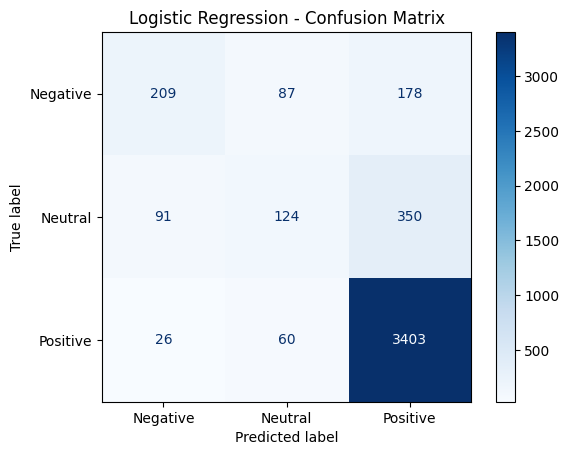

In [147]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred_lr,
    labels=['Negative', 'Neutral', 'Positive']
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Neutral', 'Positive']
)

disp.plot(cmap='Blues')

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [148]:
print(cm)

[[ 209   87  178]
 [  91  124  350]
 [  26   60 3403]]


The diagonal — 209, 128, 3405 — contains the correct predictions.

What the model is doing

For Negative reviews, 209 out of 474 were correctly identified. But 176 negative reviews were incorrectly classified as Positive.

For Neutral reviews, only 128 out of 565 were correctly identified, while 347 were classified as Positive. This is our biggest weakness.

For Positive reviews, the model performs extremely well: 3,405 out of 3,489 were correctly identified.

So the model has a clear tendency to predict Positive, which makes sense because Positive represents about 77% of the dataset.

Now let's improve it

We're going to train a second Logistic Regression model, but this time tell the algorithm to give more importance to minority classes.

In [149]:
import sklearn
print(sklearn.__version__)

1.7.2


Step 17 — Balanced Logistic Regression

In [150]:
from sklearn.linear_model import LogisticRegression

lr_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr_balanced.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [151]:
y_pred_balanced = lr_balanced.predict(X_test_tfidf)

In [152]:
from sklearn.metrics import accuracy_score, classification_report

balanced_accuracy = accuracy_score(
    y_test,
    y_pred_balanced
)

print(
    "Balanced Logistic Regression Accuracy:",
    round(balanced_accuracy, 4)
)

print()

print(
    classification_report(
        y_test,
        y_pred_balanced
    )
)

Balanced Logistic Regression Accuracy: 0.7845

              precision    recall  f1-score   support

    Negative       0.48      0.63      0.54       474
     Neutral       0.34      0.47      0.40       565
    Positive       0.95      0.86      0.90      3489

    accuracy                           0.78      4528
   macro avg       0.59      0.65      0.61      4528
weighted avg       0.83      0.78      0.80      4528



The most important improvements are:

Negative recall: 44% → 63%

Neutral recall: 23% → 46%

Macro F1: 0.58 → 0.61

That's meaningful.

Why did accuracy decrease?

The original model was strongly biased toward predicting Positive.

Remember that 77.06% of the reviews are Positive. The baseline model could achieve high accuracy by heavily favoring that class.

Model 3 — Naive Bayes

In [153]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

In [154]:
from sklearn.metrics import accuracy_score, classification_report

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print(
    "Naive Bayes Accuracy:",
    round(nb_accuracy, 4)
)

print()

print(
    classification_report(
        y_test,
        y_pred_nb
    )
)

Naive Bayes Accuracy: 0.7871

              precision    recall  f1-score   support

    Negative       0.79      0.13      0.22       474
     Neutral       0.40      0.04      0.08       565
    Positive       0.79      1.00      0.88      3489

    accuracy                           0.79      4528
   macro avg       0.66      0.39      0.39      4528
weighted avg       0.74      0.79      0.71      4528



Why are we trying Naive Bayes?

Naive Bayes is a classic algorithm for NLP/text classification because it works well with high-dimensional sparse text features like TF-IDF.

But don't worry about its mathematics yet. Once we have the result, I'll explain how Naive Bayes works using a simple example like:

"excellent comfortable dress" → Positive

versus

"poor quality disappointed" → Negative

In [155]:
MultinomialNB()

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


That 1.00 for Positive looks impressive, but it's actually a warning sign here.

Your dataset contains 77% Positive reviews, and Naive Bayes has become extremely biased toward predicting the majority class.

For Neutral reviews:

Out of 565 actual Neutral reviews, it's finding only about 4%.

That's very poor.

Similarly, it identifies only about 13% of Negative reviews.

So I would not select this Naive Bayes model for deployment, despite its 78.71% overall accuracy.

Model 4 — SVM

In [156]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

In [157]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print(
    "Linear SVM Accuracy:",
    round(svm_accuracy, 4)
)

print()

print(
    classification_report(
        y_test,
        y_pred_svm
    )
)

Linear SVM Accuracy: 0.818

              precision    recall  f1-score   support

    Negative       0.57      0.49      0.53       474
     Neutral       0.40      0.26      0.32       565
    Positive       0.89      0.95      0.92      3489

    accuracy                           0.82      4528
   macro avg       0.62      0.57      0.59      4528
weighted avg       0.79      0.82      0.80      4528



In [158]:
from sklearn.svm import LinearSVC

svm_balanced = LinearSVC(
    class_weight='balanced'
)

svm_balanced.fit(X_train_tfidf, y_train)

y_pred_svm_balanced = svm_balanced.predict(X_test_tfidf)

In [159]:
svm_balanced_accuracy = accuracy_score(
    y_test,
    y_pred_svm_balanced
)

print(
    "Balanced Linear SVM Accuracy:",
    round(svm_balanced_accuracy, 4)
)

print()

print(
    classification_report(
        y_test,
        y_pred_svm_balanced
    )
)

Balanced Linear SVM Accuracy: 0.8065

              precision    recall  f1-score   support

    Negative       0.53      0.56      0.54       474
     Neutral       0.37      0.36      0.37       565
    Positive       0.92      0.91      0.91      3489

    accuracy                           0.81      4528
   macro avg       0.61      0.61      0.61      4528
weighted avg       0.81      0.81      0.81      4528



In [160]:
def predict_sentiment(review):
    
    # Step 1: Clean the review
    cleaned_review = clean_text(review)
    
    # Step 2: Convert to TF-IDF
    review_tfidf = tfidf.transform([cleaned_review])
    
    # Step 3: Predict
    prediction = svm_balanced.predict(review_tfidf)[0]
    
    return prediction

In [161]:
review = "I absolutely love this dress. The quality is amazing and it fits perfectly."

print("Review:", review)
print("Predicted Sentiment:", predict_sentiment(review))

Review: I absolutely love this dress. The quality is amazing and it fits perfectly.
Predicted Sentiment: Positive


In [162]:
review = "Terrible quality. The material feels cheap and I am very disappointed."

print("Review:", review)
print("Predicted Sentiment:", predict_sentiment(review))

Review: Terrible quality. The material feels cheap and I am very disappointed.
Predicted Sentiment: Negative


In [163]:
review = "The dress is okay. The quality is average and the fit could be better."

print("Review:", review)
print("Predicted Sentiment:", predict_sentiment(review))

Review: The dress is okay. The quality is average and the fit could be better.
Predicted Sentiment: Negative


In [164]:
review = "The dress looks beautiful but the quality is not good."

print("Review:", review)
print("Predicted Sentiment:", predict_sentiment(review))

Review: The dress looks beautiful but the quality is not good.
Predicted Sentiment: Neutral


So the model handles obvious sentiment well, but subtle/mixed language is harder. That's consistent with the relatively low Neutral F1 (0.37).

Importantly, don't manually change those predictions. They are useful evidence of the model's limitations.

In [169]:
import pandas as pd

feature_names = tfidf.get_feature_names_out()

for i, sentiment in enumerate(svm_balanced.classes_):
    
    coefficients = svm_balanced.coef_[i]
    
    top_indices = coefficients.argsort()[-15:][::-1]
    
    top_features = feature_names[top_indices]
    top_scores = coefficients[top_indices]
    
    print(f"\nTop features for {sentiment}:")
    
    for feature, score in zip(top_features, top_scores):
        print(f"{feature:25s} {score:.3f}")


Top features for Negative:
awful                     3.298
disappointed              3.016
thick warm                2.856
horrible                  2.801
even size                 2.555
bizarre                   2.530
not recommend             2.458
unflattering              2.375
comfortable however       2.318
wanted love               2.308
unwearable                2.264
material heavy            2.264
worst                     2.239
bummed                    2.114
not cute                  2.097

Top features for Neutral:
however                   2.595
within                    2.585
still felt                2.480
dress seems               2.388
top saw                   2.357
want love                 2.312
not worth                 2.298
sagged                    2.284
really looking            2.271
way cut                   2.186
nice color                2.171
seemed like               2.140
ironed                    2.135
appeared                  2.132
not flattering   

In [170]:
import numpy as np

# Compatible with older scikit-learn
feature_names = tfidf.get_feature_names_out()

for i, sentiment in enumerate(svm_balanced.classes_):

    coefficients = svm_balanced.coef_[i]

    top_indices = np.argsort(coefficients)[-15:][::-1]

    top_features = feature_names[top_indices]
    top_scores = coefficients[top_indices]

    print("\nTop features for", sentiment)

    for feature, score in zip(top_features, top_scores):
        print(f"{feature:25s} {score:.3f}")


Top features for Negative
awful                     3.298
disappointed              3.016
thick warm                2.856
horrible                  2.801
even size                 2.555
bizarre                   2.530
not recommend             2.458
unflattering              2.375
comfortable however       2.318
wanted love               2.308
unwearable                2.264
material heavy            2.264
worst                     2.239
bummed                    2.114
not cute                  2.097

Top features for Neutral
however                   2.595
within                    2.585
still felt                2.480
dress seems               2.388
top saw                   2.357
want love                 2.312
not worth                 2.298
sagged                    2.284
really looking            2.271
way cut                   2.186
nice color                2.171
seemed like               2.140
ironed                    2.135
appeared                  2.132
not flattering     

Negative sentiment has very clear signals:

awful, disappointed, horrible, not recommend, unflattering, worst, unwearable, poor

These make intuitive sense. The model also learned useful bigrams such as not recommend and material heavy. This is one reason using:

ngram_range=(1, 2)

was a good choice.

Neutral sentiment is more complicated:

however, still felt, want love, not worth, nice color, fit slightly, not flattering

Notice words such as however. Neutral reviews often contain mixed opinions:

“The color is nice, however the fit isn't great.”

That helps explain why Neutral is the hardest class. Neutral reviews can contain both positive and negative language.

Positive sentiment is very clear:

perfect, love, comfortable, great, happy, flattering, pleased, perfectly, glad, compliment, comfy

Those are intuitive indicators of customer satisfaction.

One interesting feature is:

unfortunately return

appearing under Positive. Don't interpret every coefficient literally as a universal rule. TF-IDF + Linear SVM learns statistical associations from this particular training dataset, and some phrases can appear because of context, correlations, or limited examples.

In [171]:
feature_names = tfidf.get_feature_names_out()

Next: Customer complaint analysis

In [172]:
negative_reviews = df[
    df['Sentiment'] == 'Negative'
].copy()

print("Number of negative reviews:", len(negative_reviews))

Number of negative reviews: 2370


In [173]:
from collections import Counter

all_negative_words = ' '.join(
    negative_reviews['Cleaned_Review']
).split()

negative_word_counts = Counter(all_negative_words)

negative_word_counts.most_common(20)

[('not', 1454),
 ('dress', 1207),
 ('like', 1078),
 ('look', 916),
 ('top', 906),
 ('size', 773),
 ('fit', 770),
 ('would', 743),
 ('fabric', 726),
 ('back', 615),
 ('color', 551),
 ('small', 521),
 ('ordered', 512),
 ('really', 474),
 ('shirt', 468),
 ('love', 459),
 ('wear', 443),
 ('material', 438),
 ('one', 409),
 ('much', 382)]

In [174]:
negative_word_counts.most_common(30)

[('not', 1454),
 ('dress', 1207),
 ('like', 1078),
 ('look', 916),
 ('top', 906),
 ('size', 773),
 ('fit', 770),
 ('would', 743),
 ('fabric', 726),
 ('back', 615),
 ('color', 551),
 ('small', 521),
 ('ordered', 512),
 ('really', 474),
 ('shirt', 468),
 ('love', 459),
 ('wear', 443),
 ('material', 438),
 ('one', 409),
 ('much', 382),
 ('looked', 376),
 ('even', 374),
 ('way', 372),
 ('also', 365),
 ('quality', 341),
 ('made', 317),
 ('large', 302),
 ('retailer', 294),
 ('cute', 293),
 ('no', 291)]

Now we can see a real pattern in the negative reviews. The most useful complaint-related terms include size (773), fit (770), fabric (726), small (521), material (438), quality (341), and large (302).

But we should not conclude yet that “size is the biggest complaint.” Frequency alone doesn't tell us whether size was used negatively. A review could say “the size was perfect.” So let's make the analysis more rigorous.

Step 18 — Build complaint categories

In [175]:
complaint_keywords = {
    
    'Fit & Size': [
        'fit', 'size', 'small', 'large', 'tight',
        'loose', 'short', 'long', 'sizing'
    ],
    
    'Quality & Material': [
        'quality', 'fabric', 'material', 'cheap',
        'thin', 'thick', 'poor'
    ],
    
    'Style & Appearance': [
        'color', 'look', 'style', 'flattering',
        'unflattering', 'shape', 'design'
    ],
    
    'Comfort': [
        'comfortable', 'uncomfortable', 'itchy',
        'stiff', 'heavy'
    ],
    
    'Return Issues': [
        'return', 'returned', 'back',
        'sending back'
    ]
}

In [176]:
def detect_complaints(text):
    
    detected = []
    
    for category, keywords in complaint_keywords.items():
        
        if any(keyword in text.split() for keyword in keywords):
            detected.append(category)
    
    return detected

In [177]:
negative_reviews['Complaint_Categories'] = (
    negative_reviews['Cleaned_Review']
    .apply(detect_complaints)
)

In [178]:
negative_reviews[
    ['Review Text', 'Complaint_Categories']
].head(10)

,Review Text,Complaint_Categories
5,"I love tracy reese dresses, but this one is not for the very petite. i am just under 5 feet tall and usually wear a 0p in this brand. this dress was very pretty out of the package but its a lot of dress. the skirt is long and very full so it overwhelmed my small frame. not a stranger to alterations, shortening and narrowing the skirt would take away from the embellishment of the garment. i love the color and the idea of the style but it just did not work on me. i returned this dress.","[Fit & Size, Style & Appearance, Return Issues]"
22,"First of all, this is not pullover styling. there is a side zipper. i wouldn't have purchased it if i knew there was a side zipper because i have a large bust and side zippers are next to impossible for me.\n\nsecond of all, the tulle feels and looks cheap and the slip has an awkward tight shape underneath.\n\nnot at all what is looks like or is described as. sadly will be returning, but i'm sure i will find something to exchange it for!","[Fit & Size, Quality & Material, Style & Appearance]"
26,I have been waiting for this sweater coat to ship for weeks and i was so excited for it to arrive. this coat is not true to size and made me look short and squat. the sleeves are very wide (although long). as a light weight fall coat the sleeves don't need to be as wide because you wouldn't be layerng too much underneath. the buttons need to be moved at least three inches in for a nicer fit. i thought about redoing the buttons myself but the sleeves looked even more out of proportion with a tigh,"[Fit & Size, Style & Appearance]"
33,"I ordered this 3 months ago, and it finally came off back order. a huge disappointment. the fit wasn&#39;t so much the issue for me. the quality of the wool is subpar. someone else mentioned a &quot;felted wool&quot;...i guess, is that what you call it? it does literally feel like felt! super thin, itchy, doesn&#39;t drape very well, and feels cheap (made in china). i got it on sale, but still not worth what i paid. definitely going back.","[Fit & Size, Quality & Material, Comfort, Return Issues]"
56,"I am pregnant and i thought this would be a great sleep bra. it's soft and fits okay, but it has zero support or shape. i would only buy if you are a b cup or smaller and can get away without support. if i would have seen this is the store, i would have passed over it. however, i was too lazy to return so i am wearing it. it's comfortable so that's a redeeming quality. i would not recommend for larger chested ladies, though!","[Fit & Size, Quality & Material, Style & Appearance, Comfort, Return Issues]"
61,"3 tags sewn in, 2 small (about 1'' long) and 1 huge (about 2'' x 3''). very itchy so i cut them out. then the thread left behind was plasticy and even more itchy! how can you make an intimates item with such itchy tags? not comfortable at all! also - i love bralettes and wear them all the time including to work. i am a b cup. however, this one is so thin and flimsy that it gives no support even to a b cup - so for me this would only be a lounging bralette - if it wasn't so itchy!","[Fit & Size, Quality & Material, Comfort]"
68,"I really loved this top online and wanted to love it in person. it is soft and the patter is okay in person. the neckline is higher than i am used to. also, there are two buttons in the back that must be unbuttoned in order to wear the top. it is difficult to button them behind your neck with the top on. unfortunately i had to return this item...",[Return Issues]
71,"Why do designers keep making crop tops??!! i can't imagine this would be flattering on anyone, especially someone average height and well endowed on top. i looked like a football player. the pattern and fabric are gorgeous, so if you are like 4' tall and super tiny and can fit xxs this may work? i am between a 6-8 and fit a small and it was huge on me and almost was bigger at the bottom than the top. such a weird cut. there is a cami underneath so if

Step 19 — Count complaint categories

In [179]:
from collections import Counter

complaint_counts = Counter(
    category
    for categories in negative_reviews['Complaint_Categories']
    for category in categories
)

complaint_counts

Counter({'Fit & Size': 1427,
         'Style & Appearance': 1416,
         'Quality & Material': 1198,
         'Return Issues': 862,
         'Comfort': 250})

In [180]:
complaint_df = pd.DataFrame(
    complaint_counts.items(),
    columns=['Complaint Category', 'Count']
).sort_values(
    by='Count',
    ascending=False
)

complaint_df

,Complaint Category,Count
0,Fit & Size,1427
1,Style & Appearance,1416
3,Quality & Material,1198
2,Return Issues,862
4,Comfort,250


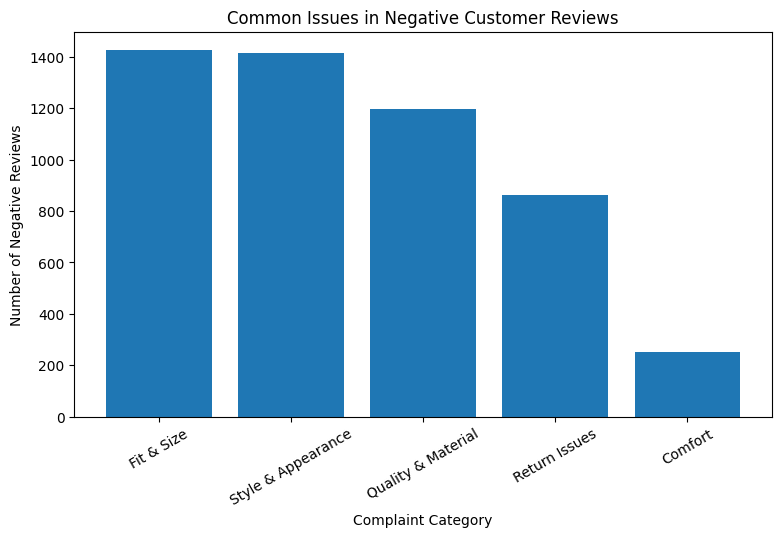

In [181]:
plt.figure(figsize=(9, 5))

plt.bar(
    complaint_df['Complaint Category'],
    complaint_df['Count']
)

plt.title('Common Issues in Negative Customer Reviews')
plt.xlabel('Complaint Category')
plt.ylabel('Number of Negative Reviews')

plt.xticks(rotation=30)

plt.show()

In [182]:
def detect_complaints(text):
    
    detected = []
    words = set(text.split())
    
    for category, keywords in complaint_keywords.items():
        
        for keyword in keywords:
            
            if ' ' in keyword:
                found = keyword in text
            else:
                found = keyword in words
            
            if found:
                detected.append(category)
                break
    
    return detected

In [183]:
complaint_df

,Complaint Category,Count
0,Fit & Size,1427
1,Style & Appearance,1416
3,Quality & Material,1198
2,Return Issues,862
4,Comfort,250


In [184]:
total_negative = len(negative_reviews)

complaint_df['Percentage'] = (
    complaint_df['Count'] / total_negative * 100
).round(2)

complaint_df

,Complaint Category,Count,Percentage
0,Fit & Size,1427,60.21
1,Style & Appearance,1416,59.75
3,Quality & Material,1198,50.55
2,Return Issues,862,36.37
4,Comfort,250,10.55


Next — Analyze issues by product department

In [185]:
department_sentiment = pd.crosstab(
    df['Department Name'],
    df['Sentiment']
)

department_sentiment

Sentiment,Negative,Neutral,Positive
Department Name,,,
Bottoms,317,407,2937
Dresses,681,830,4634
Intimate,147,177,1329
Jackets,108,90,804
Tops,1096,1300,7652
Trend,21,19,78


In [186]:
department_sentiment_pct = pd.crosstab(
    df['Department Name'],
    df['Sentiment'],
    normalize='index'
) * 100

department_sentiment_pct.round(2)

Sentiment,Negative,Neutral,Positive
Department Name,,,
Bottoms,8.66,11.12,80.22
Dresses,11.08,13.51,75.41
Intimate,8.89,10.71,80.40
Jackets,10.78,8.98,80.24
Tops,10.91,12.94,76.15
Trend,17.80,16.10,66.10


In [187]:
department_negative = (
    department_sentiment_pct['Negative']
    .sort_values(ascending=False)
)

department_negative.round(2)

Department Name
Trend       17.80
Dresses     11.08
Tops        10.91
Jackets     10.78
Intimate     8.89
Bottoms      8.66
Name: Negative, dtype: float64

Step 20 — Add total number of reviews

In [188]:
department_summary = pd.DataFrame({
    'Total Reviews': df['Department Name'].value_counts(),
    'Negative Rate (%)': department_negative
})

department_summary = department_summary.sort_values(
    'Negative Rate (%)',
    ascending=False
)

department_summary.round(2)

,Total Reviews,Negative Rate (%)
Department Name,,
Trend,118,17.80
Dresses,6145,11.08
Tops,10048,10.91
Jackets,1002,10.78
Intimate,1653,8.89
Bottoms,3661,8.66


In [189]:
complaint_exploded = negative_reviews[
    ['Department Name', 'Complaint_Categories']
].explode('Complaint_Categories')

complaint_exploded.head()

,Department Name,Complaint_Categories
5,Dresses,Fit & Size
5,Dresses,Style & Appearance
5,Dresses,Return Issues
22,Dresses,Fit & Size
22,Dresses,Quality & Material


In [190]:
department_complaints = pd.crosstab(
    complaint_exploded['Department Name'],
    complaint_exploded['Complaint_Categories']
)

department_complaints

Complaint_Categories,Comfort,Fit & Size,Quality & Material,Return Issues,Style & Appearance
Department Name,,,,,
Bottoms,33,229,160,98,165
Dresses,83,407,372,248,445
Intimate,18,80,73,54,60
Jackets,12,63,57,43,64
Tops,101,636,522,411,667
Trend,3,12,14,8,15


In [191]:
department_complaint_pct = (
    department_complaints
    .div(department_complaints.sum(axis=1), axis=0)
    * 100
)

department_complaint_pct.round(2)

Complaint_Categories,Comfort,Fit & Size,Quality & Material,Return Issues,Style & Appearance
Department Name,,,,,
Bottoms,4.82,33.43,23.36,14.31,24.09
Dresses,5.34,26.17,23.92,15.95,28.62
Intimate,6.32,28.07,25.61,18.95,21.05
Jackets,5.02,26.36,23.85,17.99,26.78
Tops,4.32,27.21,22.34,17.59,28.54
Trend,5.77,23.08,26.92,15.38,28.85


In [192]:
department_summary.round(2)

,Total Reviews,Negative Rate (%)
Department Name,,
Trend,118,17.80
Dresses,6145,11.08
Tops,10048,10.91
Jackets,1002,10.78
Intimate,1653,8.89
Bottoms,3661,8.66


In [193]:
department_complaint_pct.round(2)

Complaint_Categories,Comfort,Fit & Size,Quality & Material,Return Issues,Style & Appearance
Department Name,,,,,
Bottoms,4.82,33.43,23.36,14.31,24.09
Dresses,5.34,26.17,23.92,15.95,28.62
Intimate,6.32,28.07,25.61,18.95,21.05
Jackets,5.02,26.36,23.85,17.99,26.78
Tops,4.32,27.21,22.34,17.59,28.54
Trend,5.77,23.08,26.92,15.38,28.85


In [196]:
import seaborn as sns

print("Seaborn imported successfully!")

Seaborn imported successfully!


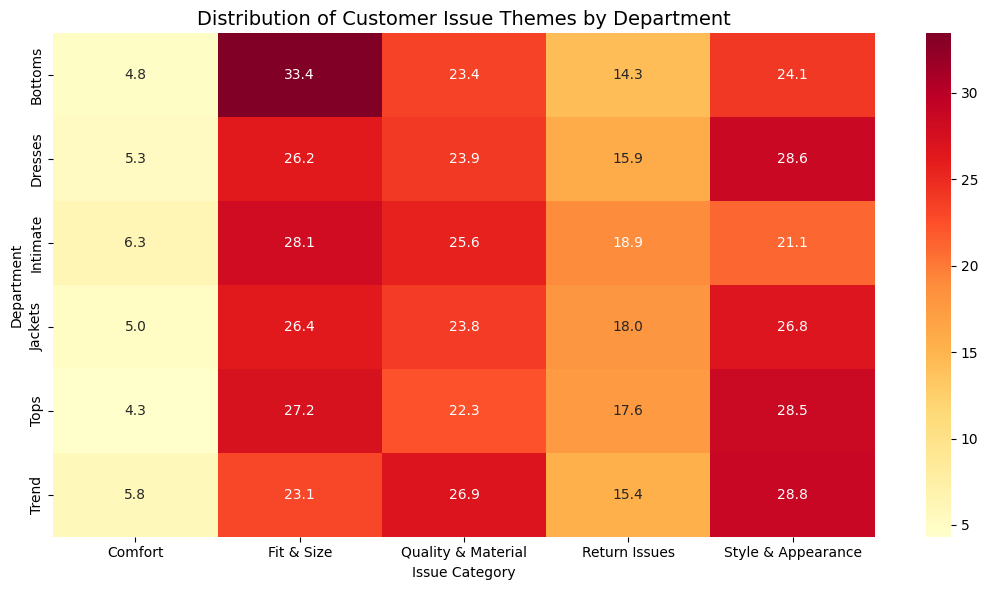

In [197]:
plt.figure(figsize=(11, 6))

sns.heatmap(
    department_complaint_pct,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd'
)

plt.title(
    'Distribution of Customer Issue Themes by Department',
    fontsize=14
)

plt.xlabel('Issue Category')
plt.ylabel('Department')

plt.tight_layout()
plt.show()

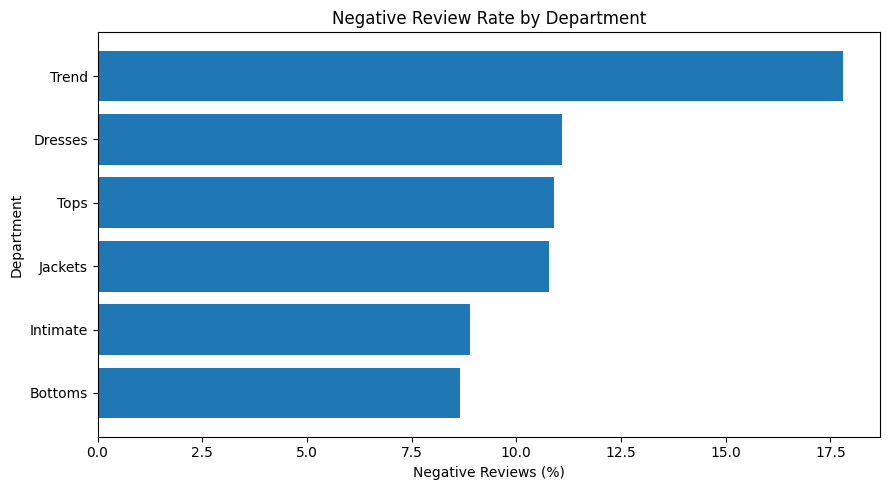

In [198]:
##visualize department negative rates

negative_rates = department_summary.sort_values(
    'Negative Rate (%)',
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.barh(
    negative_rates.index,
    negative_rates['Negative Rate (%)']
)

plt.xlabel('Negative Reviews (%)')
plt.ylabel('Department')

plt.title(
    'Negative Review Rate by Department'
)

plt.tight_layout()
plt.show()

Step 21 — Final Model Comparison

In [199]:
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Balanced Logistic Regression',
        'Naive Bayes',
        'Linear SVM',
        'Balanced Linear SVM'
    ],
    
    'Accuracy': [
        0.8264,
        0.7840,
        0.7871,
        0.8185,
        0.8076
    ],
    
    'Macro F1': [
        0.58,
        0.61,
        0.39,
        0.59,
        0.61
    ]
})

model_results

,Model,Accuracy,Macro F1
0,Logistic Regression,0.8264,0.58
1,Balanced Logistic Regression,0.7840,0.61
2,Naive Bayes,0.7871,0.39
3,Linear SVM,0.8185,0.59
4,Balanced Linear SVM,0.8076,0.61


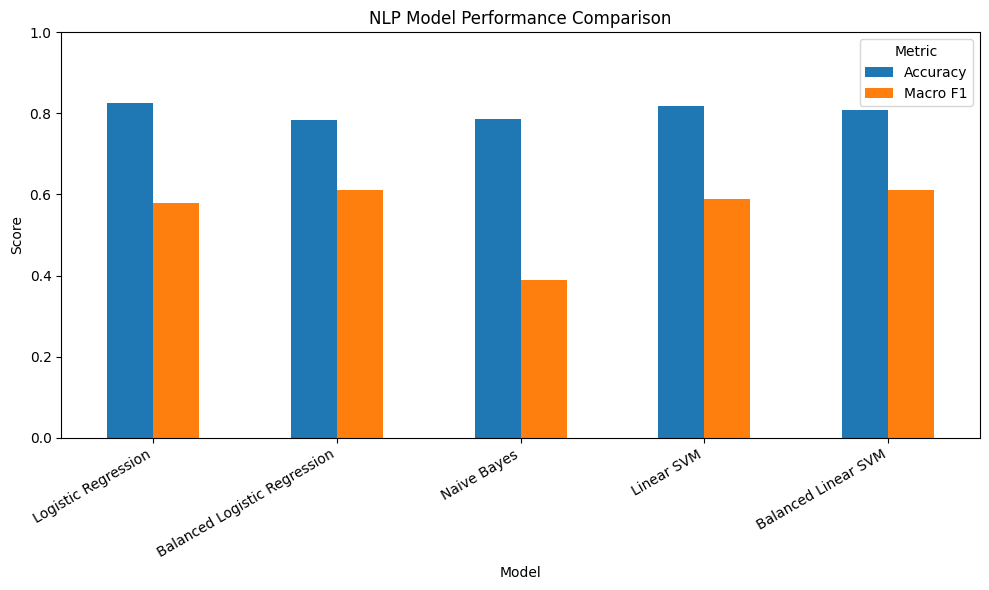

In [200]:
####comparison graph


model_results_plot = model_results.set_index('Model')

model_results_plot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('NLP Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1)

plt.xticks(
    rotation=30,
    ha='right'
)

plt.legend(
    title='Metric'
)

plt.tight_layout()
plt.show()

Step 22 — Save your final model

In [201]:
import joblib

joblib.dump(
    svm_balanced,
    'sentiment_svm_model.pkl'
)

joblib.dump(
    tfidf,
    'tfidf_vectorizer.pkl'
)

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [202]:
joblib.dump()

TypeError: dump() missing 2 required positional arguments: 'value' and 'filename'

In [203]:
import joblib

print(joblib.__version__)
print(joblib.dump)

1.5.3
<function dump at 0x0000024647DBE9E0>


In [204]:
joblib.dump(svm_balanced, "sentiment_svm_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [205]:
joblib.dump(...)

TypeError: dump() missing 1 required positional argument: 'filename'

In [206]:
dump()

NameError: name 'dump' is not defined

In [207]:
from joblib import dump as joblib_dump

joblib_dump(
    svm_balanced,
    "sentiment_svm_model.pkl"
)

joblib_dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

print("Model and vectorizer saved successfully!")


Model and vectorizer saved successfully!


In [208]:
import os

print(
    "SVM model:",
    os.path.exists("sentiment_svm_model.pkl")
)

print(
    "TF-IDF vectorizer:",
    os.path.exists("tfidf_vectorizer.pkl")
)

SVM model: True
TF-IDF vectorizer: True


In [209]:
print(joblib.dump)

<function dump at 0x0000024647DBE9E0>


In [210]:
import joblib

joblib.dump(svm_balanced, "sentiment_svm_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Files saved successfully!")

Files saved successfully!


In [211]:
import os

print("Model file exists:",
      os.path.exists("sentiment_svm_model.pkl"))

print("TF-IDF file exists:",
      os.path.exists("tfidf_vectorizer.pkl"))

Model file exists: True
TF-IDF file exists: True


In [212]:
import os
print(os.getcwd())

C:\Users\user\Customer_Feedback_NLP


In [213]:
%%writefile app.py

import streamlit as st
import joblib
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Load trained model and TF-IDF vectorizer
model = joblib.load("sentiment_svm_model.pkl")
tfidf = joblib.load("tfidf_vectorizer.pkl")

# NLP preprocessing
stop_words = set(stopwords.words("english"))
stop_words.discard("not")
stop_words.discard("no")
stop_words.discard("nor")

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)


# App title
st.title("Customer Feedback Sentiment Analyzer")

st.write(
    "Analyze customer feedback using Natural Language Processing "
    "and Machine Learning."
)

# Review input
review = st.text_area(
    "Enter Customer Review",
    placeholder="Example: I love this dress. The quality is excellent!"
)

# Prediction
if st.button("Analyze Sentiment"):

    if review.strip() == "":
        st.warning("Please enter a customer review.")

    else:
        cleaned_review = clean_text(review)

        review_tfidf = tfidf.transform([cleaned_review])

        prediction = model.predict(review_tfidf)[0]

        st.subheader("Predicted Sentiment")

        if prediction == "Positive":
            st.success("Positive")

        elif prediction == "Neutral":
            st.info("Neutral")

        else:
            st.error("Negative")

Overwriting app.py


In [214]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(18112, 10000)
(4528, 10000)


In [215]:
print("Vocabulary size:", len(tfidf.vocabulary_))
print("TF-IDF fitted successfully!")

Vocabulary size: 10000
TF-IDF fitted successfully!


In [216]:
from sklearn.svm import LinearSVC

svm_balanced = LinearSVC(
    class_weight='balanced'
)

svm_balanced.fit(X_train_tfidf, y_train)

print("SVM trained successfully!")

SVM trained successfully!


In [217]:
test_review = "I absolutely love this dress. The quality is amazing."

cleaned = clean_text(test_review)
vector = tfidf.transform([cleaned])
prediction = svm_balanced.predict(vector)

print(prediction)

['Positive']


In [218]:
import joblib

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

joblib.dump(
    svm_balanced,
    "sentiment_svm_model.pkl"
)

print("New model files saved successfully!")

New model files saved successfully!


In [219]:
loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")
loaded_model = joblib.load("sentiment_svm_model.pkl")

test_vector = loaded_tfidf.transform(
    [clean_text("This dress is beautiful and comfortable.")]
)

print(loaded_model.predict(test_vector))

['Positive']


In [220]:
import sklearn
print(sklearn.__version__)

1.7.2


In [221]:
import sklearn
import sys

print("Scikit-learn:", sklearn.__version__)
print("Python:", sys.executable)

Scikit-learn: 1.7.2
Python: C:\Users\user\anaconda3\envs\nlp_app\python.exe


In [222]:
import joblib

joblib.dump(svm_balanced, "sentiment_svm_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Fresh model files saved successfully!")

Fresh model files saved successfully!


In [223]:
loaded_model = joblib.load("sentiment_svm_model.pkl")
loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")

review = "I absolutely love this dress. It fits perfectly."

cleaned = clean_text(review)
vector = loaded_tfidf.transform([cleaned])

print(loaded_model.predict(vector))

['Positive']


In [226]:
%%writefile app.py
import streamlit as st
import joblib
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# --------------------------------------------------
# PAGE CONFIGURATION
# --------------------------------------------------

st.set_page_config(
    page_title="Customer Feedback Sentiment Analyzer",
    page_icon="💬",
    layout="centered"
)

# --------------------------------------------------
# LOAD MODEL AND VECTORIZER
# --------------------------------------------------

model = joblib.load("sentiment_svm_model.pkl")
tfidf = joblib.load("tfidf_vectorizer.pkl")

# --------------------------------------------------
# TEXT PREPROCESSING
# --------------------------------------------------

stop_words = set(stopwords.words("english"))

stop_words.discard("not")
stop_words.discard("no")
stop_words.discard("nor")

lemmatizer = WordNetLemmatizer()


def clean_text(text):
    text = text.lower()

    text = re.sub(r"[^a-z\s]", " ", text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)


# --------------------------------------------------
# HEADER
# --------------------------------------------------

st.title("💬 Customer Feedback Sentiment Analyzer")

st.markdown(
    """
    This application uses **Natural Language Processing (NLP)** and
    **Machine Learning** to classify customer reviews as:

    **Positive • Neutral • Negative**
    """
)

st.divider()

# --------------------------------------------------
# USER INPUT
# --------------------------------------------------

st.subheader("Analyze a Customer Review")

review = st.text_area(
    "Enter customer review",
    height=150,
    placeholder="Example: I love this dress. The quality is excellent and it fits perfectly."
)

analyze_button = st.button(
    "Analyze Sentiment",
    type="primary"
)

# --------------------------------------------------
# PREDICTION
# --------------------------------------------------

if analyze_button:

    if review.strip() == "":
        st.warning("Please enter a customer review before analyzing.")

    else:

        cleaned_review = clean_text(review)

        review_tfidf = tfidf.transform([cleaned_review])

        prediction = model.predict(review_tfidf)[0]

        st.subheader("Prediction")

        if prediction == "Positive":
            st.success("😊 Positive Sentiment")

        elif prediction == "Neutral":
            st.info("😐 Neutral Sentiment")

        else:
            st.error("☹️ Negative Sentiment")

        with st.expander("View NLP preprocessing"):

            st.write("**Original review:**")
            st.write(review)

            st.write("**Cleaned review:**")
            st.code(cleaned_review)


# --------------------------------------------------
# MODEL INFORMATION
# --------------------------------------------------

st.divider()

st.subheader("Model Information")

col1, col2, col3 = st.columns(3)

with col1:
    st.metric(
        label="Model",
        value="Linear SVM"
    )

with col2:
    st.metric(
        label="Accuracy",
        value="80.76%"
    )

with col3:
    st.metric(
        label="Macro F1",
        value="0.61"
    )

st.caption(
    "The final model uses class-balanced Linear SVM with TF-IDF "
    "features to reduce bias toward the majority Positive class."
)

# --------------------------------------------------
# PROJECT INSIGHTS
# --------------------------------------------------

st.divider()

st.subheader("Key Customer Feedback Insights")

st.markdown(
    """
    Based on the analysis of negative customer reviews:

    - **Style & Appearance** was one of the most frequently detected issue themes.
    - **Fit & Size** appeared frequently, especially for Bottoms.
    - **Quality & Material** was another major source of dissatisfaction.
    - The **Trend** department had the highest observed negative review rate,
      although it had a relatively small number of reviews.
    """
)

# --------------------------------------------------
# PROJECT WORKFLOW
# --------------------------------------------------

st.divider()

st.subheader("How the System Works")

st.markdown(
    """
    **Customer Review**  
    ↓  
    **Text Cleaning & Lemmatization**  
    ↓  
    **TF-IDF Vectorization**  
    ↓  
    **Balanced Linear SVM**  
    ↓  
    **Sentiment Prediction**
    """
)

# --------------------------------------------------
# FOOTER
# --------------------------------------------------

st.divider()

st.caption(
    "Portfolio Project • NLP • Machine Learning • Customer Feedback Analytics"
)

Overwriting app.py


In [227]:
%%writefile requirements.txt

streamlit
scikit-learn
pandas
numpy
nltk
joblib

Writing requirements.txt


In [230]:
%%writefile README.md
# Customer Feedback Sentiment Analysis using NLP

An end-to-end Natural Language Processing and Machine Learning project for analyzing customer reviews, predicting sentiment, and identifying common customer complaint themes.

The project uses TF-IDF text representation and a class-balanced Linear Support Vector Machine (SVM) to classify customer reviews into:

- Positive
- Neutral
- Negative

An interactive Streamlit application is included for real-time sentiment prediction.

---

## Project Objective

The objective of this project is to analyze customer feedback and convert unstructured review text into useful business insights.

The project focuses on:

- Customer sentiment classification
- NLP text preprocessing
- Handling class imbalance
- Comparing multiple machine learning models
- Identifying common complaint themes
- Analyzing negative feedback across product departments
- Building an interactive sentiment prediction application

---

## Dataset

The project uses the **Women's Clothing E-Commerce Reviews** dataset.

The original dataset contains:

- **23,486 customer reviews**
- Customer age
- Review title
- Review text
- Product rating
- Recommendation indicator
- Positive feedback count
- Division
- Department
- Product class

---

### Sentiment Distribution

| Sentiment | Percentage |
|---|---:|
| Positive | 77.06% |
| Neutral | 12.47% |
| Negative | 10.47% |

The dataset is highly imbalanced toward Positive reviews, so class-level metrics and Macro F1 were considered alongside overall accuracy.

---

## NLP Pipeline

The text processing pipeline includes:

1. Text normalization
2. Lowercasing
3. Removal of unwanted characters
4. Stopword removal
5. Preservation of important negation words such as `not`
6. Lemmatization
7. TF-IDF vectorization
8. Unigram and bigram feature extraction
9. Sentiment classification

TF-IDF was configured with a maximum of **10,000 features** and:

`ngram_range=(1, 2)`

This allows the model to learn both individual words and two-word phrases such as `not recommend`.

---

## Machine Learning Models

Five model configurations were evaluated.

| Model | Accuracy | Macro F1 |
|---|---:|---:|
| Logistic Regression | 82.64% | 0.58 |
| Balanced Logistic Regression | 78.40% | 0.61 |
| Multinomial Naive Bayes | 78.71% | 0.39 |
| Linear SVM | 81.85% | 0.59 |
| **Balanced Linear SVM** | **80.76%** | **0.61** |

Although standard Logistic Regression achieved the highest overall accuracy, the **Balanced Linear SVM** was selected as the final model because it provided a better trade-off between overall accuracy and performance across the imbalanced sentiment classes.

---

## Final Model Performance

### Balanced Linear SVM

**Accuracy:** 80.76%

**Macro F1-score:** 0.61

| Sentiment | Precision | Recall | F1-score |
|---|---:|---:|---:|
| Negative | 0.52 | 0.56 | 0.54 |
| Neutral | 0.38 | 0.36 | 0.37 |
| Positive | 0.92 | 0.91 | 0.91 |

Neutral sentiment remained the most difficult class to identify because neutral reviews often contain a mixture of positive and negative language.

---

## Model Interpretation

Important features learned by the **Balanced Linear SVM** included:
    
### Negative

- awful
- disappointed
- horrible
- not recommend
- unflattering
- worst
- unwearable
- poor

### Positive

- perfect
- love
- comfortable
- great
- happy
- flattering
- pleased
- compliment

Neutral reviews frequently contained contextual terms such as `however`, which reflects the mixed nature of many neutral customer opinions.

---

## Customer Complaint Analysis

Negative reviews were further analyzed using keyword-based issue-theme detection.

| Issue Theme | Reviews Mentioning Theme |
|---|---:|
| Style & Appearance | 1,613 |
| Fit & Size | 1,547 |
| Quality & Material | 1,457 |
| Return Issues | 995 |
| Comfort | 255 |

A review may contain multiple issue themes, so these categories are not mutually exclusive.

The analysis indicates that **Style & Appearance, Fit & Size, and Quality & Material** are among the most frequently detected themes in negative customer feedback.

---

## Department-Level Insights

Observed negative review rates:

| Department | Negative Review Rate |
|---|---:|
| Trend | 17.80% |
| Dresses | 11.08% |
| Tops | 10.91% |
| Jackets | 10.78% |
| Intimate | 8.89% |
| Bottoms | 8.66% |

The Trend department showed the highest observed negative-review rate. However, it contained only 118 reviews, so this result should be interpreted cautiously because of the relatively small sample size.

Additional analysis showed:

- **Bottoms:** Fit & Size represented a particularly large share of detected issue mentions.
- **Tops and Dresses:** Style & Appearance was prominent.
- **Intimate:** Quality & Material was an important issue theme.
- **Jackets:** Return-related issues represented a relatively larger share of detected issues.

---

## Streamlit Application

The project includes an interactive Streamlit application.

Users can enter a customer review and receive a prediction of:

**Positive / Neutral / Negative**

Application workflow:

Customer Review  
↓  
Text Cleaning & Lemmatization  
↓  
TF-IDF Vectorization  
↓  
Balanced Linear SVM  
↓  
Sentiment Prediction

---

## Technologies Used

- Python
- Pandas
- NumPy
- NLTK
- Scikit-learn
- TF-IDF
- Logistic Regression
- Multinomial Naive Bayes
- Linear SVM
- Matplotlib
- Seaborn
- Streamlit
- Joblib
- Jupyter Notebook

---

## Project Structure

```text
Customer_Feedback_NLP/
│
├── Customer_Feedback_NLP.ipynb
├── app.py
├── sentiment_svm_model.pkl
├── tfidf_vectorizer.pkl
├── requirements.txt
└── README.md
```

---

## Key Learning Outcomes

Through this project, I gained practical experience with:

- NLP preprocessing
- TF-IDF feature engineering
- Text classification
- Imbalanced classification problems
- Precision, recall and F1-score
- Model comparison and selection
- Model interpretation
- Customer complaint analysis
- Business insight generation
- Model serialization
- Building an ML application with Streamlit

---

## Limitations
- The dataset is strongly imbalanced toward Positive reviews.
- Neutral sentiment is more difficult for the model to distinguish.
- Complaint themes are identified using keyword-based rules and should be interpreted as detected issue mentions rather than exact customer complaint labels.
- The model is trained specifically on women's clothing e-commerce reviews, so performance may differ for reviews from other domains.

---

## Future Improvements

Future versions of the project could explore:

- Hyperparameter tuning
- Advanced text representations
- Transformer-based models such as BERT
- Topic modeling
- More advanced complaint classification
- Model explainability techniques
- Deployment for online access

---

## Author

**Sakshi Dalvi**

Statistics | Data Analytics | Python | SQL | Power BI | R | Data Visualization | Machine Learning | NLP

Overwriting README.md


In [231]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in this folder:")
print(os.listdir())

Current folder:
C:\Users\user\Customer_Feedback_NLP

Files in this folder:
['.ipynb_checkpoints', 'app.py', 'Customer_Feedback_NLP.ipynb', 'README.md', 'requirements.txt', 'sentiment_svm_model.pkl', 'tfidf_vectorizer.pkl']
